# **PROJECT NAME**

$\color{red}{\text{Smoking Healthcare Analysis}}$

image healthcare.avif

**Using Python (Pandas, Numpy, Visualization)**

# **OBJECTIVE**

To analyze smoking-related health data and identify which organs and medical conditions are most affected using data analysis and visualization techniques.

# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **LOAD DATASETS**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving condition.csv to condition.csv
Saving health_dataset.csv to health_dataset (1).csv
Saving Image Dataset.csv to Image Dataset.csv
Saving Organs.csv to Organs.csv


In [ ]:
health = pd.read_csv("health_dataset.csv")
organs = pd.read_csv("Organs.csv")
conditions = pd.read_csv("condition.csv")
image = pd.read_csv("Image Dataset.csv")

# **BASIC DATA UNDERSTANDING**

In [ ]:
health.head()

,Patient_ID,Age,Gender,Smoking_Status,Years_of_Smoking,Cigarettes_Per_Day,Organ,Organ_Condition,BMI,BP_Risk,Cholesterol_Level,Family_History_Risk,Alcohol_Consumption
0,1,32,Male,Never,0,0,Liver,Healthy,28.1,Low,202.7,No,Low
1,2,47,Female,Former,2,8,Lungs,Healthy,21.6,Normal,214.5,No,Low
2,3,77,Female,Former,10,12,Heart,Healthy,41.6,Normal,274.8,No,Low
3,4,77,Female,Never,0,0,Lungs,Healthy,17.4,Normal,163.4,No,Moderate
4,5,53,Female,Current,39,18,Kidney,Healthy,30.0,Normal,153.3,No,Moderate


In [ ]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2500 non-null   int64  
 1   Age                  2500 non-null   int64  
 2   Gender               2500 non-null   object 
 3   Smoking_Status       2500 non-null   object 
 4   Years_of_Smoking     2500 non-null   int64  
 5   Cigarettes_Per_Day   2500 non-null   int64  
 6   Organ                2500 non-null   object 
 7   Organ_Condition      2500 non-null   object 
 8   BMI                  2500 non-null   float64
 9   BP_Risk              2500 non-null   object 
 10  Cholesterol_Level    2500 non-null   float64
 11  Family_History_Risk  2500 non-null   object 
 12  Alcohol_Consumption  2500 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 254.0+ KB


In [ ]:
health.describe()

,Patient_ID,Age,Years_of_Smoking,Cigarettes_Per_Day,BMI,Cholesterol_Level
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,54.031600,8.976800,6.833200,29.620680,207.785600
std,721.83216,20.793738,11.155144,8.341583,7.239672,52.852446
min,1.00000,18.000000,0.000000,0.000000,17.000000,120.000000
25%,625.75000,36.000000,0.000000,0.000000,23.600000,161.700000
50%,1250.50000,54.000000,4.000000,3.000000,29.400000,206.650000
75%,1875.25000,72.000000,16.000000,12.000000,35.900000,253.625000
max,2500.00000,89.000000,39.000000,29.000000,42.000000,300.000000


In [ ]:
organs.head()

,Organ,Icon_URL
0,Human Body,https://drive.google.com/thumbnail?id=10eszInx...
1,Heart,https://drive.google.com/thumbnail?id=1HfZPQzc...
2,Lungs,https://drive.google.com/thumbnail?id=1uY6iARe...
3,Kidney,https://drive.google.com/thumbnail?id=1ZY34NSn...
4,Liver,https://drive.google.com/thumbnail?id=1q1vqEjv...


In [ ]:
conditions.head()

,Organ_Condition
0,Healthy
1,Damaged


# **DATA CLEANING**

**CHECK MISSING VALUES**

In [ ]:
health.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Smoking_Status,0
Years_of_Smoking,0
Cigarettes_Per_Day,0
Organ,0
Organ_Condition,0
BMI,0
BP_Risk,0


# **MERGE DATASETS**

In [ ]:
df = health.merge(organs, on="Organ", how="left")\
     .merge(conditions, on="Organ_Condition", how="left")

I combined multiple datasets to build a unified analytical view

# **EDA**

1. Organ vs Smoking impact

In [ ]:
df.groupby("Organ")["Cigarettes_Per_Day"].mean().sort_values(ascending=False)

,Cigarettes_Per_Day
Organ,
Heart,7.391304
Lungs,6.935146
Kidney,6.682979
Human Body,6.620253
Liver,6.519126


2. Smoking vs BP Risk

In [ ]:
df.groupby("Smoking_Status")["BP_Risk"].value_counts()

Smoking_Status  BP_Risk
Current         Normal     421
                High       169
                Low        143
Former          Normal     335
                High       176
                Low        120
Never           Normal     640
                High       284
                Low        212
Name: count, dtype: int64

3. Smoking vs Cholesterol

In [ ]:
df.groupby("Smoking_Status")["Cholesterol_Level"].mean()

,Cholesterol_Level
Smoking_Status,
Current,211.127694
Former,207.577971
Never,205.744454


4. Age vs Smoking

In [ ]:
df.groupby("Smoking_Status")["Age"].mean()

,Age
Smoking_Status,
Current,54.919509
Former,52.732171
Never,54.180458


**1. Organ vs Smoking impact (Bar Chart)**

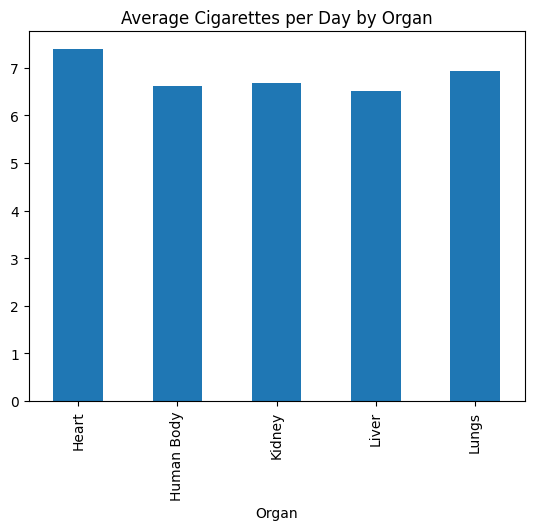

In [ ]:
df.groupby("Organ")["Cigarettes_Per_Day"].mean().plot(kind="bar")
plt.title("Average Cigarettes per Day by Organ")
plt.show()

This chart indicates that certain organs are associated with higher smoking intensity, suggesting a stronger impact of smoking on those areas.

**2. Smoking vs BP Risk (Bar Chart)**

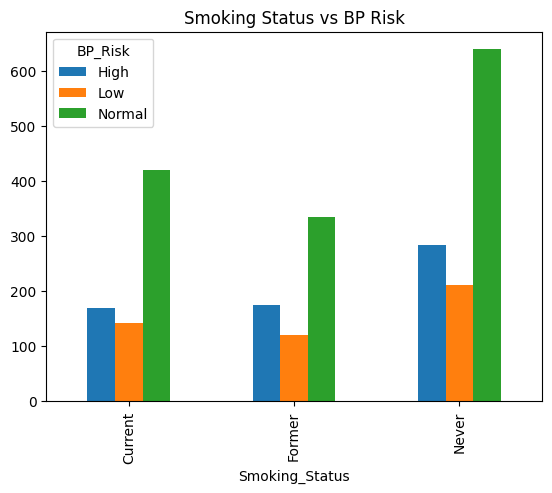

In [ ]:
df.groupby("Smoking_Status")["BP_Risk"].value_counts().unstack().plot(kind="bar")
plt.title("Smoking Status vs BP Risk")
plt.show()

We can observe that smokers are more likely to fall into higher BP risk categories, indicating a potential link between smoking and blood pressure issues.

**3. Smoking vs Cholesterol**

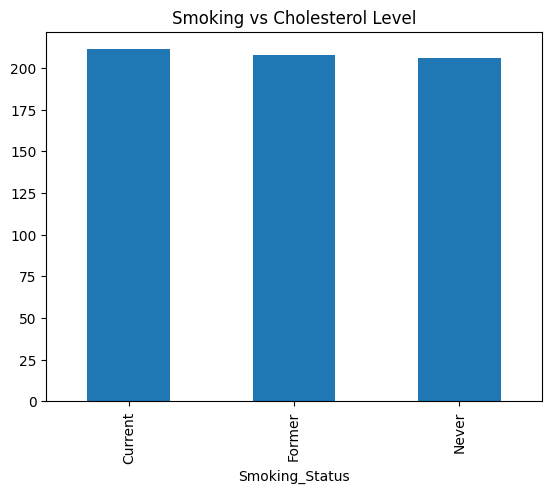

In [ ]:
df.groupby("Smoking_Status")["Cholesterol_Level"].mean().plot(kind="bar")
plt.title("Smoking vs Cholesterol Level")
plt.show()

The chart shows that smokers tend to have higher average cholesterol levels, suggesting increased cardiovascular risk.

**4. Age vs Smoking**

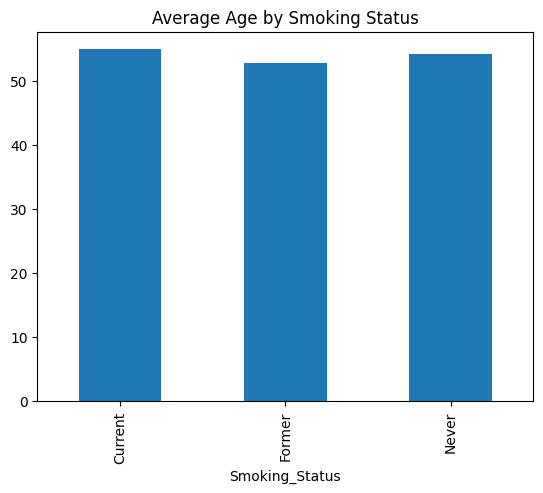

In [ ]:
df.groupby("Smoking_Status")["Age"].mean().plot(kind="bar")
plt.title("Average Age by Smoking Status")
plt.show()

This visualization highlights differences in average age across smoking groups, suggesting variations in smoking behavior across age demographics.

# **CONCLUSION**

This analysis helps the company identify high-risk patients based on smoking behavior and supports better healthcare decision-making by enabling early intervention, targeted treatment plans, and more focused preventive care strategies.